# pandapower 入门：把“潮流仿真”理解成一次网络状态计算

> 面向本仓库后续的低压配电网 / PV / BESS / CVaR 实验。  
> 目标不是补一门《电力系统分析》，而是先做到：**看得懂、改得动、知道结果代表什么。**

导师课题里最终要做的事情可以压缩成：

```text
负荷 / 光伏 / 储能功率
        ↓
写入 pandapower 网络
        ↓
pp.runpp()
        ↓
节点电压 / 线路负载 / 变压器负载 / 与上级电网交换功率 / 网损
```

**一句话心智模型：**

> 潮流计算不是在“预测未来”，而是在回答：当这一时刻各节点的负荷、光伏和储能功率已经给定时，电网会处于什么状态？

本 notebook 先用一个很小的 0.4 kV 辐射型台区建立直觉，再衔接仓库已有的 IEEE 33-bus + CVaR 复现。

## 0. 先只认识 6 个对象

| pandapower 对象 | 直觉 | 常用字段 |
|---|---|---|
| `bus` | 节点 / 母线 | `vn_kv` |
| `ext_grid` | 上级电网，负责兜底平衡 | `vm_pu` |
| `line` | 线路 | 长度、R、X、最大电流 |
| `load` | 用电负荷 | `p_mw`, `q_mvar` |
| `sgen` | PV 等分布式电源 | `p_mw`, `q_mvar` |
| `storage` | 储能 | `p_mw`, `soc_percent`, `max_e_mwh` |

### 本 notebook 最重要的符号约定

- `load.p_mw > 0`：用电；
- `sgen.p_mw > 0`：发电；
- `storage.p_mw > 0`：**充电**（从电网吸收功率）；
- `storage.p_mw < 0`：**放电**（向电网注入功率）；
- `res_ext_grid.p_mw > 0`：上级电网向台区供电；
- `res_ext_grid.p_mw < 0`：台区向上级电网反送。

后面反复用到的，就是这套符号。

In [1]:
# 如果环境里还没有：
# pip install "pandapower>=3.5,<4" "pandas>=2.2" "matplotlib>=3.8"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pandapower as pp
import pandapower.networks as pn

print("pandapower version:", pp.__version__)

pandapower version: 3.5.4


## 1. 搭一个能看懂的“小台区”

网络结构：

```text
10 kV 上级电网
      |
   400 kVA
  10/0.4 kV
    配变
      |
    LV-0 -------- LV-1 -------- LV-2 -------- LV-3
                    |             |             |
                  负荷1         负荷2         负荷3
                                                |
                                      后面再接 PV / BESS
```

这里故意不用复杂标准网络。先把“谁接在哪个节点”看明白，比一上来面对 33 个节点有效得多。

In [2]:
def build_demo_net():
    net = pp.create_empty_network(name="LV feeder tutorial")

    # 1) bus：节点
    b_hv = pp.create_bus(net, vn_kv=10.0, name="HV-10kV")
    b0 = pp.create_bus(net, vn_kv=0.4, name="LV-0")
    b1 = pp.create_bus(net, vn_kv=0.4, name="LV-1")
    b2 = pp.create_bus(net, vn_kv=0.4, name="LV-2")
    b3 = pp.create_bus(net, vn_kv=0.4, name="LV-3")

    # 2) ext_grid：上级电网 / 平衡节点
    pp.create_ext_grid(net, bus=b_hv, vm_pu=1.0, name="Upstream grid")

    # 3) transformer：10/0.4 kV，400 kVA
    pp.create_transformer(
        net,
        hv_bus=b_hv,
        lv_bus=b0,
        std_type="0.4 MVA 10/0.4 kV",
        name="T1",
    )

    # 4) line：三段低压线。这里只为教学采用一组典型化参数
    line_par = dict(
        r_ohm_per_km=0.642,
        x_ohm_per_km=0.083,
        c_nf_per_km=210.0,
        max_i_ka=0.142,
        type="cs",
    )
    pp.create_line_from_parameters(net, b0, b1, length_km=0.08, name="L01", **line_par)
    pp.create_line_from_parameters(net, b1, b2, length_km=0.10, name="L12", **line_par)
    pp.create_line_from_parameters(net, b2, b3, length_km=0.12, name="L23", **line_par)

    # 5) load：20/25/30 kW
    pp.create_load(net, bus=b1, p_mw=0.020, q_mvar=0.006, name="Load-1")
    pp.create_load(net, bus=b2, p_mw=0.025, q_mvar=0.008, name="Load-2")
    pp.create_load(net, bus=b3, p_mw=0.030, q_mvar=0.010, name="Load-3")

    return net, {"hv": b_hv, "lv0": b0, "lv1": b1, "lv2": b2, "lv3": b3}

net, bus = build_demo_net()
base_load_p = net.load["p_mw"].copy()
base_load_q = net.load["q_mvar"].copy()

print(net)

This pandapower network includes the following parameter tables:
   - bus (5 elements)
   - load (3 elements)
   - ext_grid (1 element)
   - line (3 elements)
   - trafo (1 element)


### pandapower 的一个关键特点：网络本质上就是一组 pandas DataFrame

所以别把它想成一个神秘的“电力仿真软件黑盒”。

- `net.bus`：节点表；
- `net.line`：线路表；
- `net.load`：负荷表；
- `net.sgen`：分布式电源表；
- 跑完潮流后会多出 `net.res_*` 结果表。

先看看输入。

In [3]:
display(net.bus[["name", "vn_kv"]])
display(net.line[["name", "from_bus", "to_bus", "length_km", "r_ohm_per_km", "x_ohm_per_km"]])
display(net.load[["name", "bus", "p_mw", "q_mvar"]])

,name,vn_kv
0,HV-10kV,10.0
1,LV-0,0.4
2,LV-1,0.4
3,LV-2,0.4
4,LV-3,0.4


,name,from_bus,to_bus,length_km,r_ohm_per_km,x_ohm_per_km
0,L01,1,2,0.08,0.642,0.083
1,L12,2,3,0.10,0.642,0.083
2,L23,3,4,0.12,0.642,0.083


,name,bus,p_mw,q_mvar
0,Load-1,2,0.020,0.006
1,Load-2,3,0.025,0.008
2,Load-3,4,0.030,0.010


## 2. 第一次潮流：只有负荷，没有 PV、没有储能

真正的“潮流仿真”调用只有一行：

```python
pp.runpp(net)
```

对这种辐射型配电网，这里使用 `bfsw`（Backward/Forward Sweep）算法。

你暂时不用推交流潮流方程。先把它当成：

```text
网络参数 + 每个节点的 P/Q
          ↓
       求一个平衡解
          ↓
每个节点电压 + 每条线上的功率/电流 + 上级电网出力
```

In [4]:
pp.runpp(
    net,
    algorithm="bfsw",
    calculate_voltage_angles=False,
    voltage_depend_loads=False,
)

print("converged:", net.converged)

display(net.res_bus[["vm_pu", "p_mw", "q_mvar"]])
display(net.res_line[["loading_percent", "pl_mw"]])
display(net.res_trafo[["loading_percent", "pl_mw"]])
display(net.res_ext_grid[["p_mw", "q_mvar"]])

numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)


converged: True


,vm_pu,p_mw,q_mvar
0,1.000000,-0.080512,-0.025222
1,0.994992,0.000000,0.000000
2,0.968384,0.020000,0.006000
3,0.943758,0.025000,0.008000
4,0.927507,0.030000,0.010000


,loading_percent,pl_mw
0,84.839840,0.002236
1,62.925575,0.001538
2,34.655612,0.000560


,loading_percent,pl_mw
0,21.09259,0.001179


,p_mw,q_mvar
0,0.080512,0.025222


### 现在先只会读 5 个结果

1. **`res_bus.vm_pu`**：节点电压标幺值。  
   - 1.00 p.u. ≈ 额定电压；
   - 0.97 p.u. 表示比额定值低约 3%；
   - 1.05 p.u. 表示高约 5%。

2. **`res_line.loading_percent`**：线路负载率。

3. **`res_trafo.loading_percent`**：配变负载率。

4. **`res_ext_grid.p_mw`**：台区与上级电网交换的有功功率。

5. **`res_line.pl_mw`**：线路有功损耗。

这已经覆盖导师材料里后续 AC 潮流回放的大部分核心指标。

In [5]:
def snapshot(net, label):
    return {
        "case": label,
        "V_min_pu": net.res_bus.vm_pu.min(),
        "V_max_pu": net.res_bus.vm_pu.max(),
        "P_grid_MW": net.res_ext_grid.p_mw.iloc[0],
        "trafo_loading_%": net.res_trafo.loading_percent.max(),
        "line_loading_max_%": net.res_line.loading_percent.max(),
        "line_loss_kW": net.res_line.pl_mw.sum() * 1000,
    }

baseline = snapshot(net, "Load only")
pd.DataFrame([baseline]).round(4)

,case,V_min_pu,V_max_pu,P_grid_MW,trafo_loading_%,line_loading_max_%,line_loss_kW
0,Load only,0.9275,1.0,0.0805,21.0926,84.8398,4.3337


## 3. 加屋顶光伏：为什么高 PV 会“抬电压、甚至反送”

把 120 kW PV 接到馈线末端 LV-3。

注意：在 pandapower 里，PV 通常用 `sgen`（static generator）表示。

In [6]:
pv_idx = pp.create_sgen(
    net,
    bus=bus["lv3"],
    p_mw=0.120,   # 120 kW
    q_mvar=0.0,
    name="PV@LV-3",
)

pp.runpp(net, algorithm="bfsw", calculate_voltage_angles=False)

with_pv = snapshot(net, "120 kW PV")
pd.DataFrame([baseline, with_pv]).round(4)

numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)


,case,V_min_pu,V_max_pu,P_grid_MW,trafo_loading_%,line_loading_max_%,line_loss_kW
0,Load only,0.9275,1.0000,0.0805,21.0926,84.8398,4.3337
1,120 kW PV,0.9989,1.0733,-0.0383,11.6262,85.7604,5.6737


观察两个方向就够了：

- PV 在馈线末端注入功率，末端电压通常会比“只有负荷”时升高；
- 当 PV 大于本地负荷与损耗后，`res_ext_grid.p_mw` 可能变成负数，即**反向潮流**。

这也是为什么“净负荷为负”和“真实电网是否出现电压问题”不是一回事：  
**净负荷是聚合功率；潮流还关心这些功率分别接在哪个节点、经过哪段线路。**

numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)


numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)


numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)


numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)


numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)


...

numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)


numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)


numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)


numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)


,PV_kW,P_grid_kW,V_end_pu,V_max_pu,trafo_loading_%,line_loading_max_%,line_loss_kW
0,0.0,80.5122,0.9275,1.0,21.0926,84.8398,4.3337
1,10.0,69.1357,0.9415,1.0,18.3699,73.7829,3.0135
2,20.0,58.1017,0.9550,1.0,15.7766,63.2586,2.0256
3,30.0,47.3809,0.9682,1.0,13.3276,53.3327,1.3419
4,40.0,36.9482,0.9810,1.0,11.0556,44.1481,0.9379


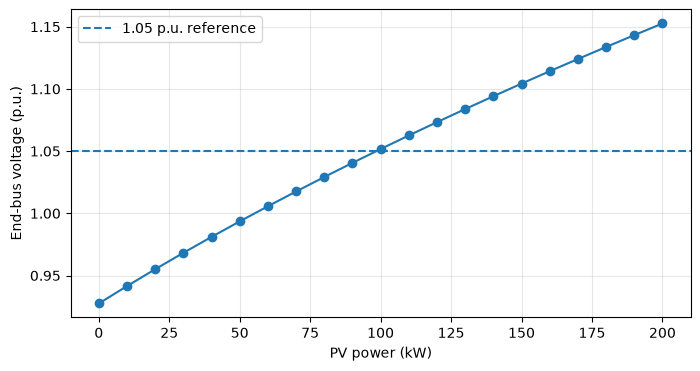

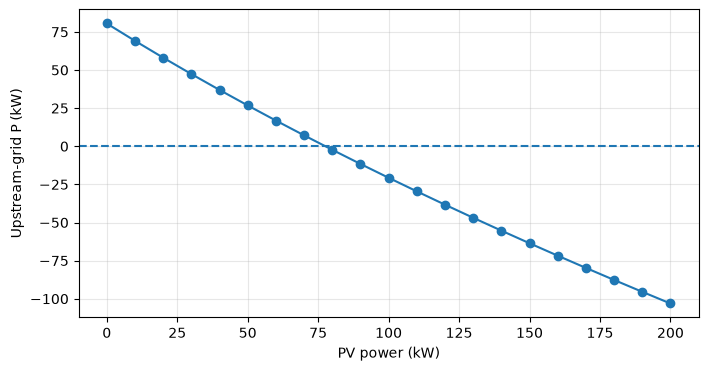

In [7]:
# 扫一遍 PV 容量，看趋势，而不是只看一个点
rows = []

for pv_mw in np.linspace(0.0, 0.20, 21):
    net.sgen.loc[pv_idx, "p_mw"] = pv_mw
    pp.runpp(net, algorithm="bfsw", calculate_voltage_angles=False)

    rows.append({
        "PV_kW": pv_mw * 1000,
        "P_grid_kW": net.res_ext_grid.p_mw.iloc[0] * 1000,
        "V_end_pu": net.res_bus.loc[bus["lv3"], "vm_pu"],
        "V_max_pu": net.res_bus.vm_pu.max(),
        "trafo_loading_%": net.res_trafo.loading_percent.max(),
        "line_loading_max_%": net.res_line.loading_percent.max(),
        "line_loss_kW": net.res_line.pl_mw.sum() * 1000,
    })

pv_sweep = pd.DataFrame(rows)
display(pv_sweep.round(4).head())

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(pv_sweep["PV_kW"], pv_sweep["V_end_pu"], marker="o")
ax.axhline(1.05, linestyle="--", label="1.05 p.u. reference")
ax.set_xlabel("PV power (kW)")
ax.set_ylabel("End-bus voltage (p.u.)")
ax.grid(alpha=0.3)
ax.legend()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(pv_sweep["PV_kW"], pv_sweep["P_grid_kW"], marker="o")
ax.axhline(0, linestyle="--")
ax.set_xlabel("PV power (kW)")
ax.set_ylabel("Upstream-grid P (kW)")
ax.grid(alpha=0.3)
plt.show()

## 4. 再加储能：储能不是“自动优化器”，只是一个可控注入/负荷

这里把储能也放在 LV-3。

最容易写反的是：

```text
storage.p_mw > 0  = 充电
storage.p_mw < 0  = 放电
```

pandapower 的潮流计算只负责“这一时刻电池功率是多少时，电网会怎样”。

**它不会在 `runpp()` 里替你更新 SOC。**  
后续课题里的 SOC 动力学、滚动优化、CVaR 决策，属于 pandapower 外面的调度层。

In [8]:
# 固定 PV 为 120 kW
net.sgen.loc[pv_idx, "p_mw"] = 0.120

storage_idx = pp.create_storage(
    net,
    bus=bus["lv3"],
    p_mw=0.0,
    q_mvar=0.0,
    max_e_mwh=0.10,   # 100 kWh
    soc_percent=50.0,
    name="BESS@LV-3",
)

storage_cases = [
    ("Charge +40 kW", +0.040),
    ("Idle",           0.000),
    ("Discharge -40 kW", -0.040),
]

rows = []
for label, p_bess in storage_cases:
    net.storage.loc[storage_idx, "p_mw"] = p_bess
    pp.runpp(net, algorithm="bfsw", calculate_voltage_angles=False)
    rows.append(snapshot(net, label))

pd.DataFrame(rows).round(4)

numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)


numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)


numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)


,case,V_min_pu,V_max_pu,P_grid_MW,trafo_loading_%,line_loading_max_%,line_loss_kW
0,Charge +40 kW,0.9978,1.0292,-0.0023,6.1235,50.3610,1.7298
1,Idle,0.9989,1.0733,-0.0383,11.6262,85.7604,5.6737
2,Discharge -40 kW,1.0000,1.1142,-0.0718,19.3129,118.9446,12.1032


### 为什么这一步对后面的论文最重要？

后续风险调度真正做的是：

```text
预测 / 场景 / CVaR
        ↓
决定未来每个时刻 BESS 的 p_mw
        ↓
每次只执行当前一步
        ↓
把真实的下一时刻 Load / PV / BESS 写进 pandapower
        ↓
runpp()
        ↓
检查电压、反送、配变/线路负载、损耗
```

所以 **CVaR 不替代潮流，潮流也不替代 CVaR**：

- CVaR/优化：决定“电池怎么动”；
- pandapower：验证“这么动以后，真实 AC 网络状态怎么样”。

In [9]:
# 一个极简 SOC 更新例子：SOC 必须自己在调度层维护
# 这里只演示符号，不是完整电池模型

dt_h = 0.5
eta_ch = 0.95
eta_dis = 0.95
e_mwh = 0.05    # 100 kWh 电池的 50% SOC
p_storage_mw = +0.040  # + 表示充电

if p_storage_mw >= 0:
    e_next = e_mwh + eta_ch * p_storage_mw * dt_h
else:
    e_next = e_mwh + (p_storage_mw / eta_dis) * dt_h

print("energy before:", e_mwh, "MWh")
print("energy after :", round(e_next, 4), "MWh")

energy before: 0.05 MWh
energy after : 0.069 MWh


## 5. 从“一次潮流”变成“时间序列回放”

导师课题里不会只算某一个时刻，而是 Final Test 全年每 30 min 回放一次。

本质上不是更神秘的算法，只是：

```python
for t in time_steps:
    写入 t 时刻的 load / PV / storage
    pp.runpp(net)
    保存 res_bus / res_line / res_trafo / res_ext_grid
```

下面先用 24 小时玩具曲线理解这个循环。

numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)


numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)


numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)


numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)


numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)


...

numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)


numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)


numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)


numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)


,hour,load_factor,PV_kW,BESS_kW,P_grid_kW,V_min_pu,V_max_pu,trafo_loading_%,line_loading_max_%,loss_kW
0,0,0.65,0.0000,0.0,51.5378,0.9540,1.0000,13.4980,53.9610,1.7460
1,1,0.60,0.0000,0.0,47.5058,0.9577,1.0000,12.4407,49.6622,1.4780
2,2,0.58,0.0000,0.0,45.9000,0.9592,1.0000,12.0197,47.9501,1.3776
3,3,0.57,0.0000,0.0,45.0986,0.9599,1.0000,11.8095,47.0957,1.3288
4,4,0.60,0.0000,0.0,47.5058,0.9577,1.0000,12.4407,49.6622,1.4780
5,5,0.70,0.0000,0.0,55.5956,0.9503,1.0000,14.5619,58.2867,2.0382
6,6,0.82,0.0000,0.0,65.4421,0.9413,1.0000,17.1431,68.7818,2.8423
7,7,0.92,38.8229,0.0,31.9192,0.9802,1.0000,9.7363,38.8000,0.7458
8,8,0.98,75.0000,0.0,0.9319,0.9968,1.0247,5.9445,46.2668,1.4654
9,9,1.00,106.0660,0.0,-26.0847,0.9986,1.0583,9.1442,73.6872,3.9892


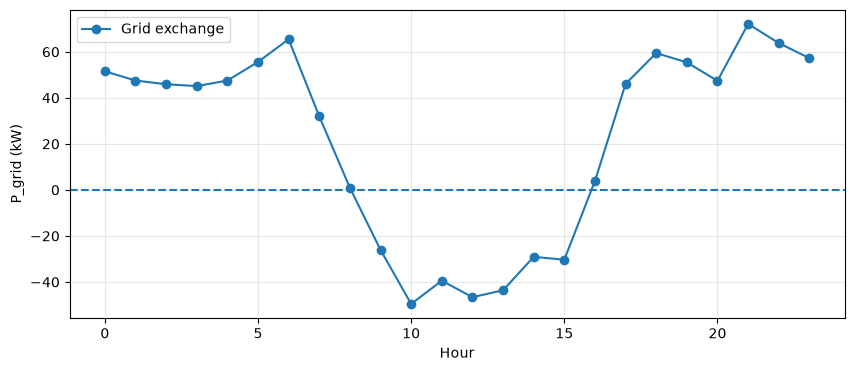

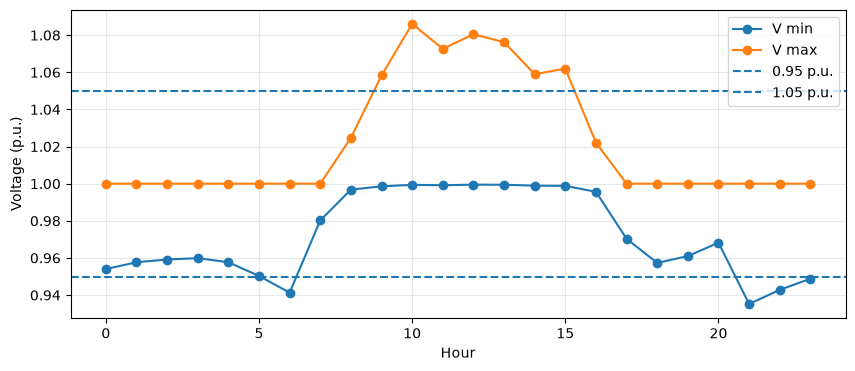

In [10]:
hours = np.arange(24)

load_factor = np.array([
    0.65,0.60,0.58,0.57,0.60,0.70,
    0.82,0.92,0.98,1.00,0.96,0.92,
    0.88,0.86,0.88,0.94,1.02,1.10,
    1.15,1.10,1.00,0.90,0.80,0.72
])

pv_factor = np.maximum(0, np.sin((hours - 6) / 12 * np.pi))
pv_profile_mw = 0.15 * pv_factor

# 只是演示一个“中午充、晚高峰放”的规则，不是优化结果
bess_profile_mw = np.zeros(24)
bess_profile_mw[11:15] = +0.030
bess_profile_mw[18:21] = -0.030

records = []

for h in hours:
    net.load.loc[:, "p_mw"] = base_load_p.values * load_factor[h]
    net.load.loc[:, "q_mvar"] = base_load_q.values * load_factor[h]
    net.sgen.loc[pv_idx, "p_mw"] = pv_profile_mw[h]
    net.storage.loc[storage_idx, "p_mw"] = bess_profile_mw[h]

    pp.runpp(net, algorithm="bfsw", calculate_voltage_angles=False)

    records.append({
        "hour": h,
        "load_factor": load_factor[h],
        "PV_kW": pv_profile_mw[h] * 1000,
        "BESS_kW": bess_profile_mw[h] * 1000,
        "P_grid_kW": net.res_ext_grid.p_mw.iloc[0] * 1000,
        "V_min_pu": net.res_bus.vm_pu.min(),
        "V_max_pu": net.res_bus.vm_pu.max(),
        "trafo_loading_%": net.res_trafo.loading_percent.max(),
        "line_loading_max_%": net.res_line.loading_percent.max(),
        "loss_kW": net.res_line.pl_mw.sum() * 1000,
    })

ts = pd.DataFrame(records)
display(ts.round(4))

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(ts["hour"], ts["P_grid_kW"], marker="o", label="Grid exchange")
ax.axhline(0, linestyle="--")
ax.set_xlabel("Hour")
ax.set_ylabel("P_grid (kW)")
ax.grid(alpha=0.3)
ax.legend()
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(ts["hour"], ts["V_min_pu"], marker="o", label="V min")
ax.plot(ts["hour"], ts["V_max_pu"], marker="o", label="V max")
ax.axhline(0.95, linestyle="--", label="0.95 p.u.")
ax.axhline(1.05, linestyle="--", label="1.05 p.u.")
ax.set_xlabel("Hour")
ax.set_ylabel("Voltage (p.u.)")
ax.grid(alpha=0.3)
ax.legend()
plt.show()

## 6. 把导师材料翻译成 pandapower 代码

后续论文里的术语，其实可以直接对应到这些对象：

| 论文里的东西 | pandapower 里怎么做 |
|---|---|
| 节点级真实负荷 | 改 `net.load.p_mw / q_mvar` |
| 节点级 PV | 改 `net.sgen.p_mw` |
| 储能调度动作 | 改 `net.storage.p_mw` |
| AC 潮流回放 | `pp.runpp(net)` |
| 最低/最高电压 | `net.res_bus.vm_pu.min()/max()` |
| 反向潮流 | `net.res_ext_grid.p_mw < 0` |
| 配变负载率 | `net.res_trafo.loading_percent` |
| 线路负载率 | `net.res_line.loading_percent` |
| 网损 | `net.res_line.pl_mw.sum()` |

这张表建议先记住，比先啃潮流公式更有用。

## 7. 衔接本仓库已有的 IEEE 33-bus + CVaR 复现

仓库里的：

```text
papers/2025-ijepes-cvar-adn/
```

已经用了同一套思路，只是网络从 4 个低压节点换成了 IEEE 33-bus：

```python
net = pn.case33bw()
...
pp.runpp(net, algorithm="bfsw")
```

你现在再看那份代码时，可以先忽略场景生成和 CVaR，只盯住三件事：

1. 它把 PV / 风机 / 储能放在哪些 bus；
2. 每个场景、每个小时怎样修改 `load/sgen/storage`；
3. `runpp()` 后从哪些 `res_*` 表读结果。

In [11]:
# 单独跑一次 IEEE 33-bus，感受“复杂网络其实接口没变”
net33 = pn.case33bw()

pp.runpp(
    net33,
    algorithm="bfsw",
    calculate_voltage_angles=False,
)

print("buses:", len(net33.bus))
print("lines:", len(net33.line))
print("loads:", len(net33.load))
print("converged:", net33.converged)
print("voltage range:",
      round(net33.res_bus.vm_pu.min(), 4),
      "~",
      round(net33.res_bus.vm_pu.max(), 4))
print("grid import MW:",
      round(net33.res_ext_grid.p_mw.iloc[0], 4))

# 论文常写 bus 1...33，而 case33bw 的 DataFrame index 从 0...32。
# 因此“论文 bus 21”通常对应 pandapower index 20。
display(net33.bus.head())

numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)


buses: 33
lines: 37
loads: 32
converged: True
voltage range: 0.9131 ~ 1.0
grid import MW: 3.9177


,name,vn_kv,type,zone,in_service,max_vm_pu,min_vm_pu,geo
0,0,12.66,b,1.0,True,1.0,1.0,"{""coordinates"": [-1.0272036165, 0.2320163609],..."
1,1,12.66,b,1.0,True,1.1,0.9,"{""coordinates"": [-1.7116237332, 1.1564808132],..."
2,2,12.66,b,1.0,True,1.1,0.9,"{""coordinates"": [-2.9808633284, 0.7559599298],..."
3,3,12.66,b,1.0,True,1.1,0.9,"{""coordinates"": [-3.522358388, 1.8171551243], ..."
4,4,12.66,b,1.0,True,1.1,0.9,"{""coordinates"": [-2.731321429, 2.6315460884], ..."


## 8. SimBench 和 pandapower 到底是什么关系？

最简单的理解：

- **SimBench**：给你“现成的、标准化的电网拓扑 + 元件 + profile”；
- **pandapower**：拿这个网络做潮流、最优潮流等计算。

也就是：

```text
SimBench：网络从哪来？
pandapower：这个网络怎么算？
```

后续课题可以像这样：

```python
import simbench as sb

net = sb.get_simbench_net("某个低压网络代码")
# 把 Ausgrid / 自己构造的节点级负荷与 PV 写进 net
pp.runpp(net)
```

所以学 pandapower 是主线；SimBench 可以等你已经能看懂 `net.bus / load / sgen / line / trafo` 后再接。

## 9. 现在真正需要记住的只有 8 行

```python
net = ...                         # 拿到 / 创建网络
net.load["p_mw"] = ...            # 写负荷
net.sgen["p_mw"] = ...            # 写 PV
net.storage["p_mw"] = ...         # 写储能动作

pp.runpp(net)                     # AC 潮流

V = net.res_bus["vm_pu"]          # 节点电压
Pgrid = net.res_ext_grid["p_mw"]  # 与上级电网交换功率
loading = net.res_line["loading_percent"]
```

### 推荐练习

1. 把 PV 从 120 kW 改成 180 kW，看 `P_grid` 和末端电压如何变化；
2. 把同样的 PV 从 LV-3 挪到 LV-1，对比电压抬升；
3. 固定 PV，在 +40 / 0 / -40 kW 三个储能动作下比较电压、反送和损耗。

如果这三个练习能自己改出来，就已经够资格开始读本仓库的 CVaR + pandapower 代码了。

---

### 下一阶段再学什么？

按课题需要，顺序建议是：

```text
本 notebook：单时刻潮流直觉
        ↓
时间序列 AC 回放
        ↓
SimBench 低压网络
        ↓
节点级 Ausgrid 负荷/PV 映射
        ↓
BESS 滚动调度动作写入
        ↓
全年 res_bus / res_line / res_trafo / res_ext_grid 指标统计
```

**暂时不需要**先系统推导 Newton-Raphson 雅可比矩阵，也不需要把潮流程序自己从零实现。